In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
def split_train_test(x, y, train_size=0.8, random_state=42):
    train_set_size = int(len(x) * train_size)
    
    np.random.seed(random_state)
    shuffled_indices = np.random.permutation(len(x))
        
    train_indices = shuffled_indices[:train_set_size]
    test_indices = shuffled_indices[train_set_size:]
    
    return x.iloc[train_indices], x.iloc[test_indices], y.iloc[train_indices], y.iloc[test_indices]

## Data Transformation

In [3]:
cancer_data = pd.read_csv("./input/breast_cancer.csv")
cancer_data.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [4]:
cancer_data = cancer_data.drop(columns=["id"])

In [5]:
x_train, x_test, y_train, y_test = split_train_test(cancer_data.drop("diagnosis", axis=1), cancer_data["diagnosis"])
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((455, 30), (114, 30), (455,), (114,))

## Data Exploration Visualizations

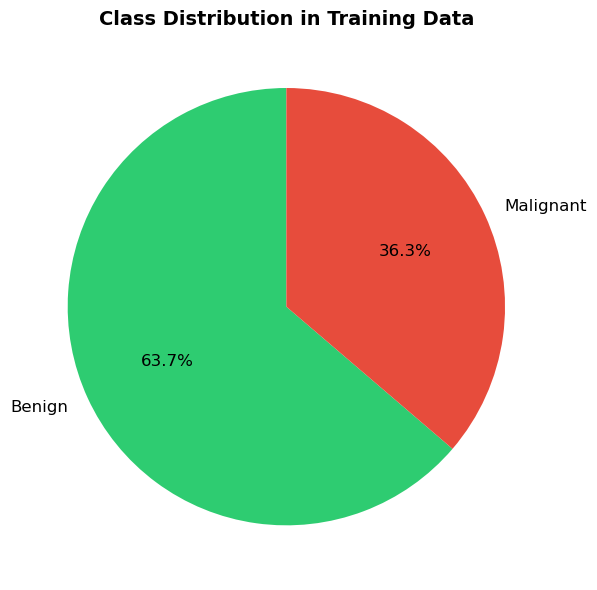

Benign: 165 (36.3%)
Malignant: 290 (63.7%)


In [6]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

benign_counts = y_train.value_counts()
labels = ["Benign", "Malignant"]
colors = ["#2ecc71", "#e74c3c"]

ax.pie(benign_counts.values, labels=labels, autopct="%1.1f%%", 
       colors=colors, startangle=90, textprops={"fontsize": 12})
ax.set_title("Class Distribution in Training Data", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Benign: {benign_counts[1]} ({benign_counts[1]/len(y_train)*100:.1f}%)")
print(f"Malignant: {benign_counts[0]} ({benign_counts[0]/len(y_train)*100:.1f}%)")

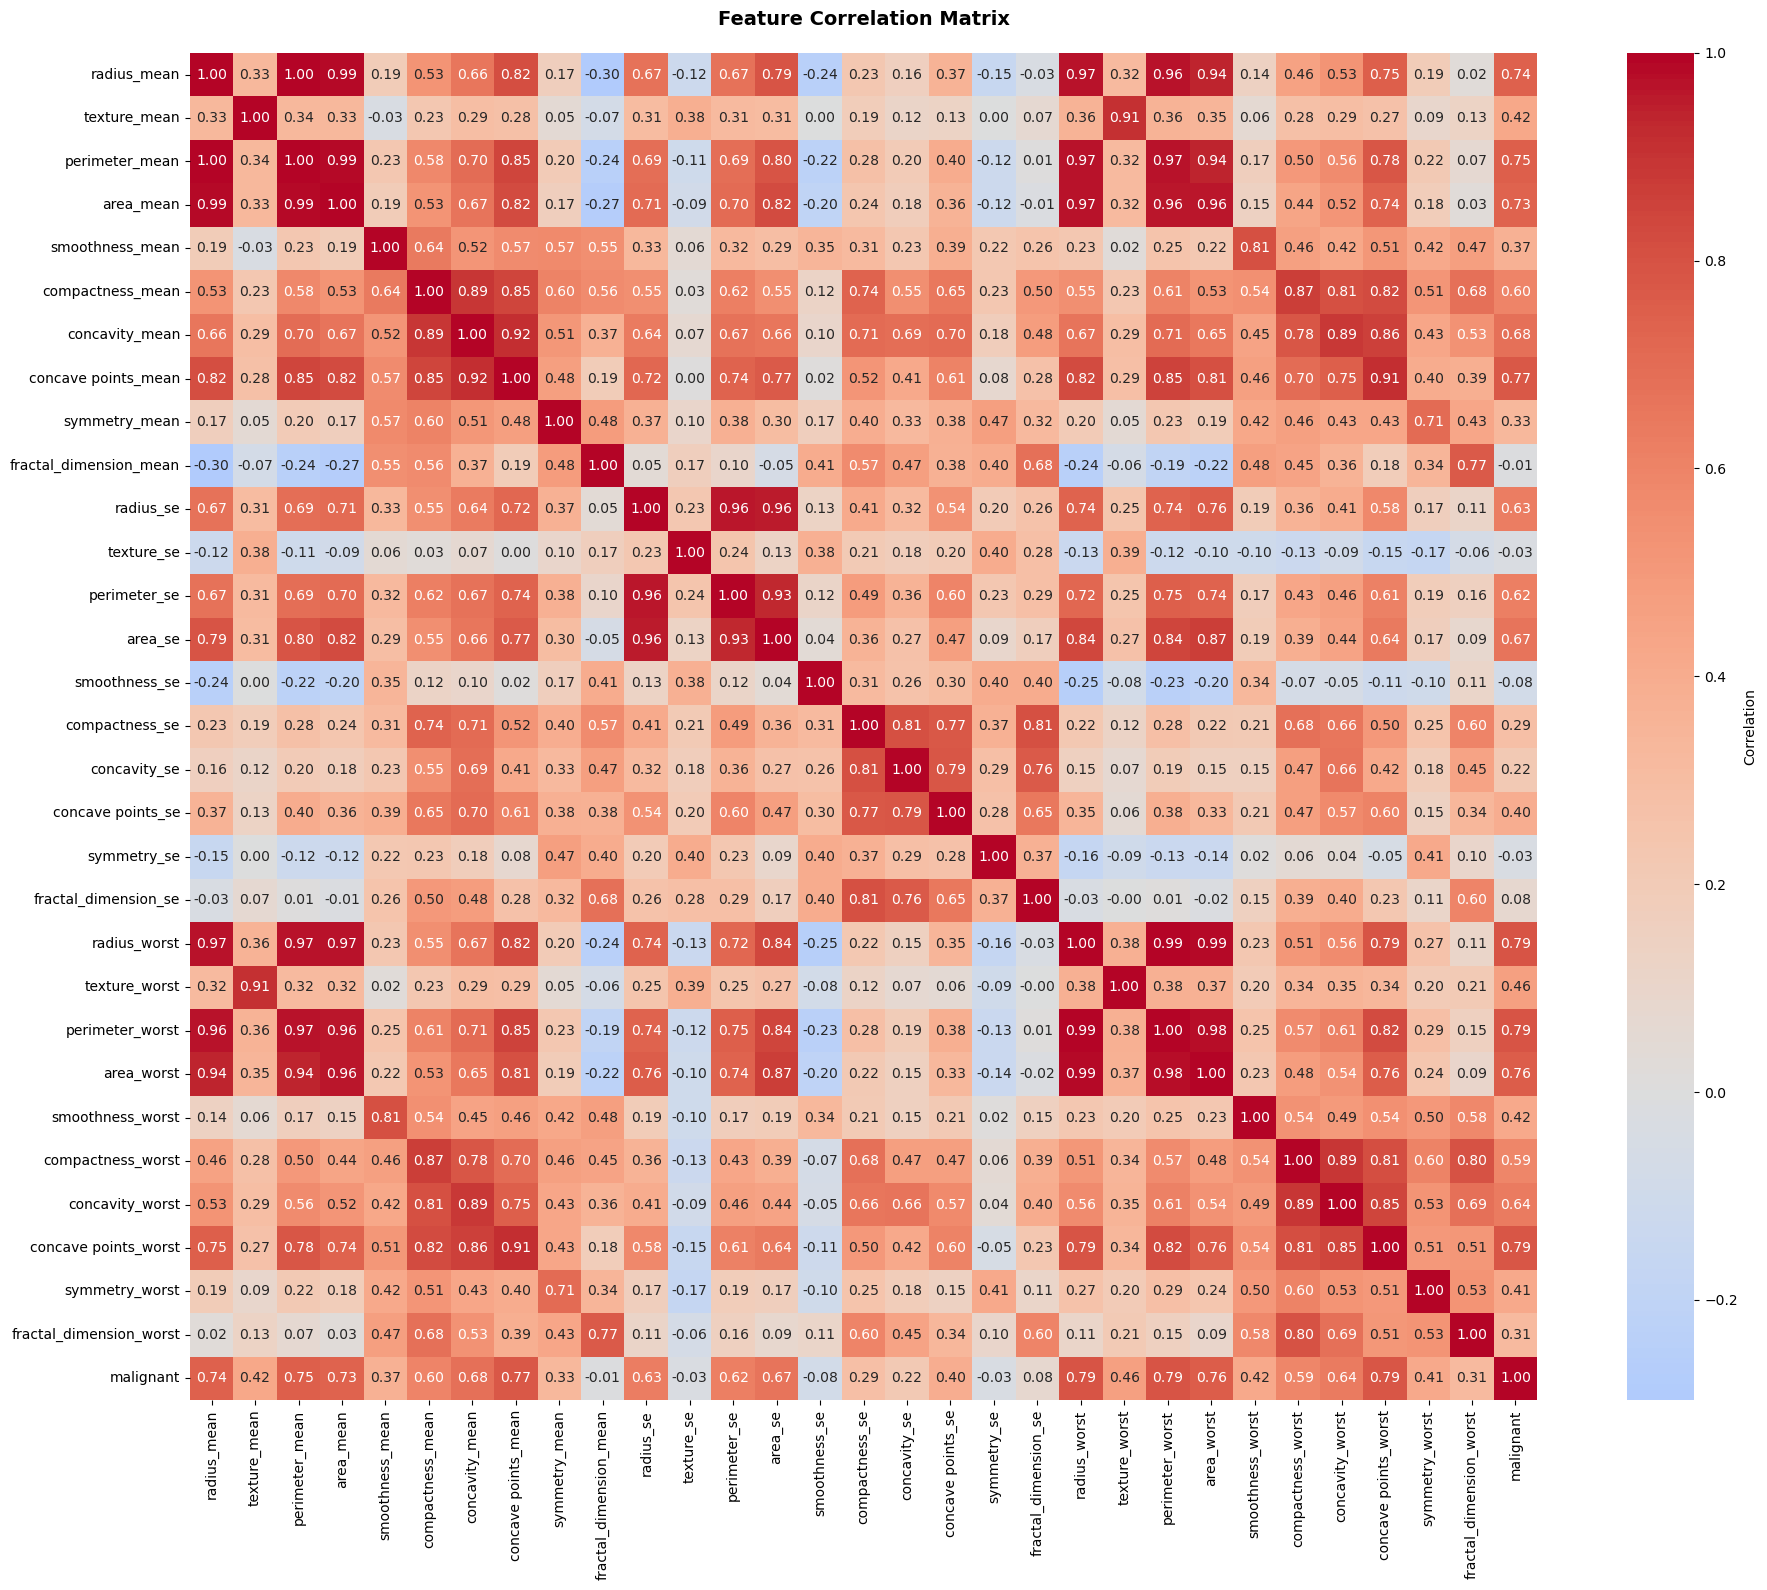

In [7]:
fig, ax = plt.subplots(figsize=(20, 16))

correlation_data = x_train.copy()
correlation_data["malignant"] = y_train.replace({"B": 0, "M": 1})

correlation_matrix = correlation_data.corr()

sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", 
            center=0, square=True, ax=ax, cbar_kws={"label": "Correlation"})
ax.set_title("Feature Correlation Matrix", fontsize=14, fontweight="bold", pad=20)
plt.tight_layout()
plt.show()

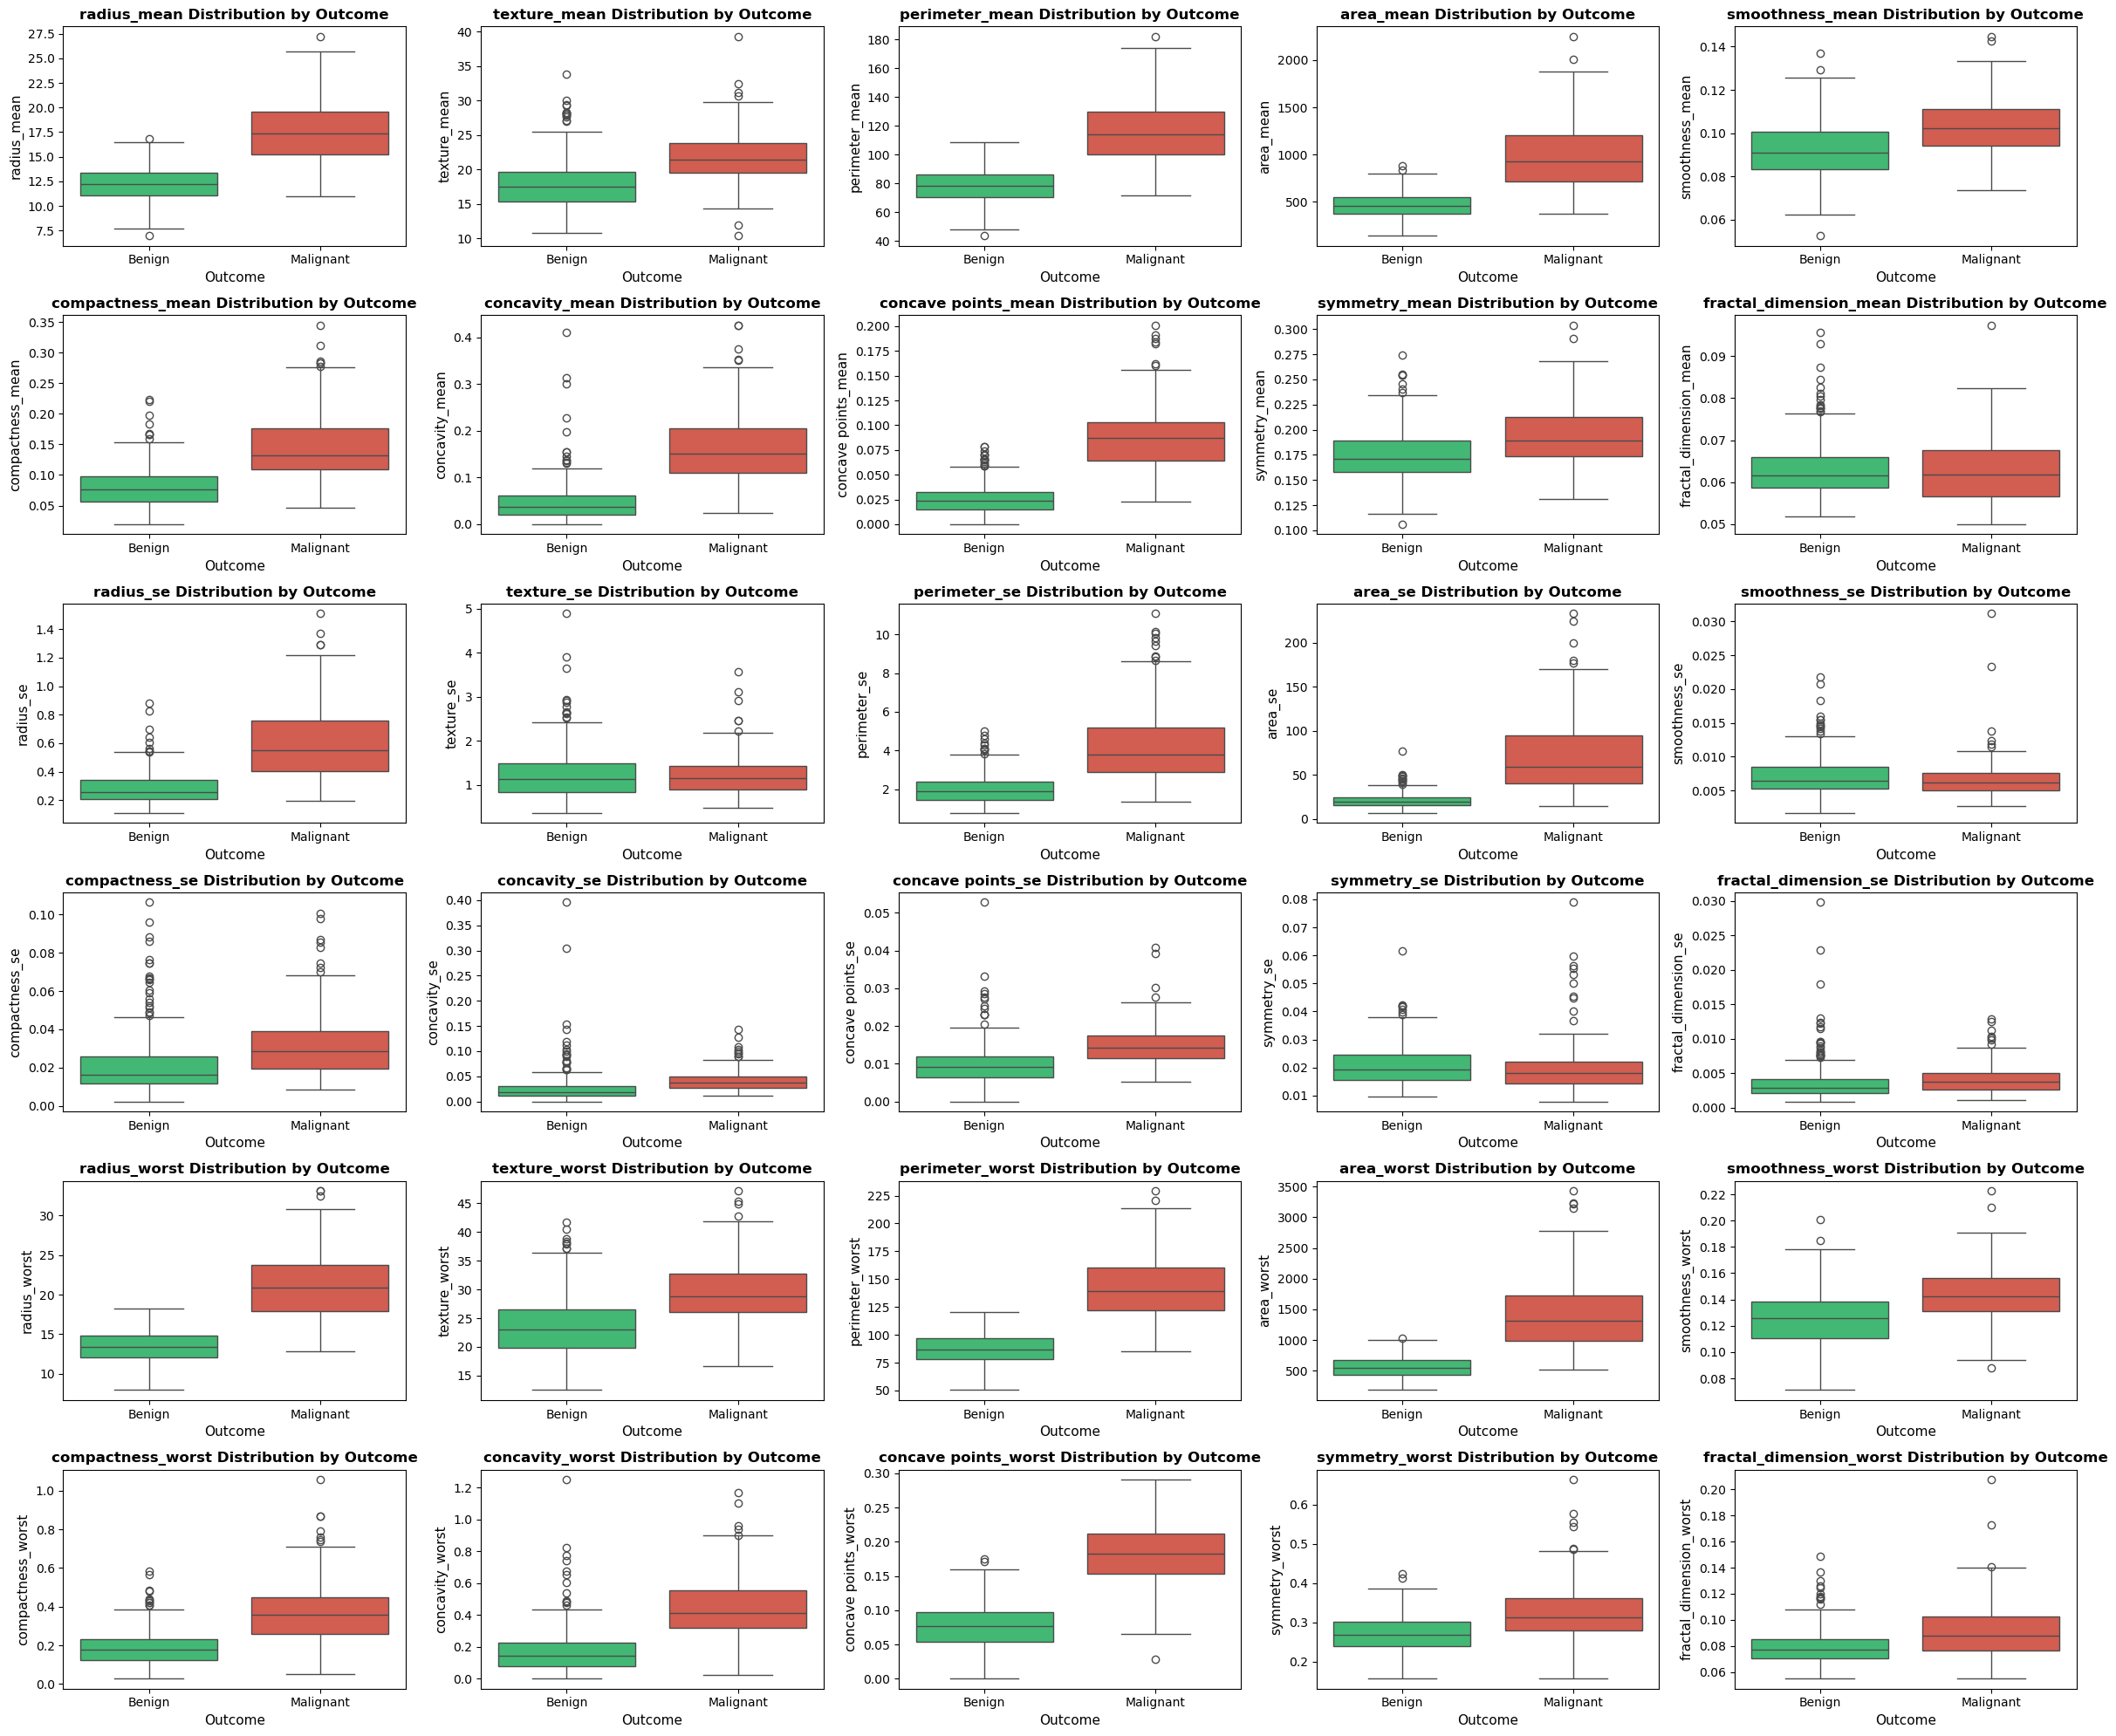

In [8]:
fig, axes = plt.subplots(6, 5, figsize=(24, 20))
axes = axes.ravel()

viz_data = x_train.copy()
viz_data["Outcome"] = y_train.replace({"B": "Benign", "M": "Malignant"})

for idx, feature in enumerate(x_train.columns):
    sns.boxplot(data=viz_data, x="Outcome", y=feature, ax=axes[idx], 
                palette=["#2ecc71", "#e74c3c"])
    axes[idx].set_title(f"{feature} Distribution by Outcome", fontsize=12, fontweight="bold")
    axes[idx].set_xlabel("Outcome", fontsize=11)
    axes[idx].set_ylabel(feature, fontsize=11)

plt.tight_layout()
plt.show()

## Model Training

In [9]:
x_train_benign = np.array(x_train[y_train == "B"])
x_train_malignant = np.array(x_train[y_train == "M"])

beningn_prior = len(x_train_benign) / len(x_train)
malignant_prior = len(x_train_malignant) / len(x_train)

x_train_benign_means = np.mean(x_train_benign, axis=0)
x_train_benign_vars = np.var(x_train_benign, axis=0)

x_train_malignant_means = np.mean(x_train_malignant, axis=0)
x_train_malignant_vars = np.var(x_train_malignant, axis=0)

priors = {
    "B": beningn_prior,
    "M": malignant_prior
}

means = {
    "B": x_train_benign_means,
    "M": x_train_malignant_means
}

variances = {
    "B": x_train_benign_vars,
    "M": x_train_malignant_vars
}

In [10]:
def compute_feature_probability(x, feature_index):
    benign_feature_mean = means["B"][feature_index]
    malignant_feature_mean = means["M"][feature_index]
    
    benign_feature_var = variances["B"][feature_index]
    malignant_feature_var = variances["M"][feature_index]
    
    a1 = 1 / np.sqrt(2 * np.pi * benign_feature_var)
    b1 = (x[feature_index] - benign_feature_mean) ** 2
    c1 = 2 * benign_feature_var
    
    benign_feature_prob = a1 * np.exp(-b1 / c1)
    
    a2 = 1 / np.sqrt(2 * np.pi * malignant_feature_var)
    b2 = (x[feature_index] - malignant_feature_mean) ** 2
    c2 = 2 * malignant_feature_var
    
    malignant_feature_prob = a2 * np.exp(-b2 / c2)
    
    return benign_feature_prob, malignant_feature_prob

In [11]:
def compute_class_probabilities(x):
    benign_score = np.log(priors["B"])
    malignant_score = np.log(priors["M"])
    
    for feature_index in range(len(x)):
        benign_feature_prob, malignant_feature_prob = compute_feature_probability(x, feature_index)
        
        benign_score += np.log(benign_feature_prob)
        malignant_score += np.log(malignant_feature_prob)
    
    return benign_score, malignant_score

## Model Evaluation

In [12]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc

In [13]:
predictions = []
probabilities = []

for idx, x in x_test.iterrows():
    survived_score, died_score = compute_class_probabilities(x)
    prediction = survived_score > died_score
    predictions.append(prediction)
    
    prob_survived = 1 / (1 + np.exp(-(survived_score - died_score)))
    probabilities.append(prob_survived)

predictions = np.array(predictions)
probabilities = np.array(probabilities)
y_test_array = y_test.replace({"B": 1, "M": 0})

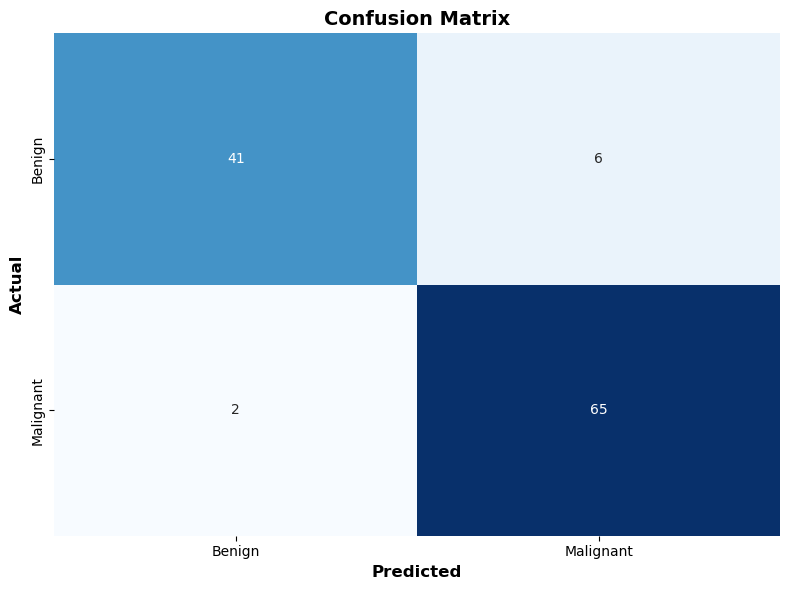

True Negatives: 41
False Positives: 6
False Negatives: 2
True Positives: 65

Sensitivity (Recall): 0.9701
Specificity: 0.8723
Precision: 0.9155
Accuracy: 0.9298
F1 Score: 0.9420


In [14]:
cm = confusion_matrix(y_test_array, predictions)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
            xticklabels=["Benign", "Malignant"], yticklabels=["Benign", "Malignant"])
ax.set_xlabel("Predicted", fontsize=12, fontweight="bold")
ax.set_ylabel("Actual", fontsize=12, fontweight="bold")
ax.set_title("Confusion Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

tn_val, fp_val, fn_val, tp_val = cm.ravel()
sensitivity = tp_val / (tp_val + fn_val)
specificity = tn_val / (tn_val + fp_val)
precision = tp_val / (tp_val + fp_val)
accuracy = (tp_val + tn_val) / (tp_val + tn_val + fp_val + fn_val)
f1_score = 2 * ((precision * sensitivity) / (precision + sensitivity))

print(f"True Negatives: {tn_val}")
print(f"False Positives: {fp_val}")
print(f"False Negatives: {fn_val}")
print(f"True Positives: {tp_val}")
print(f"\nSensitivity (Recall): {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1_score:.4f}")

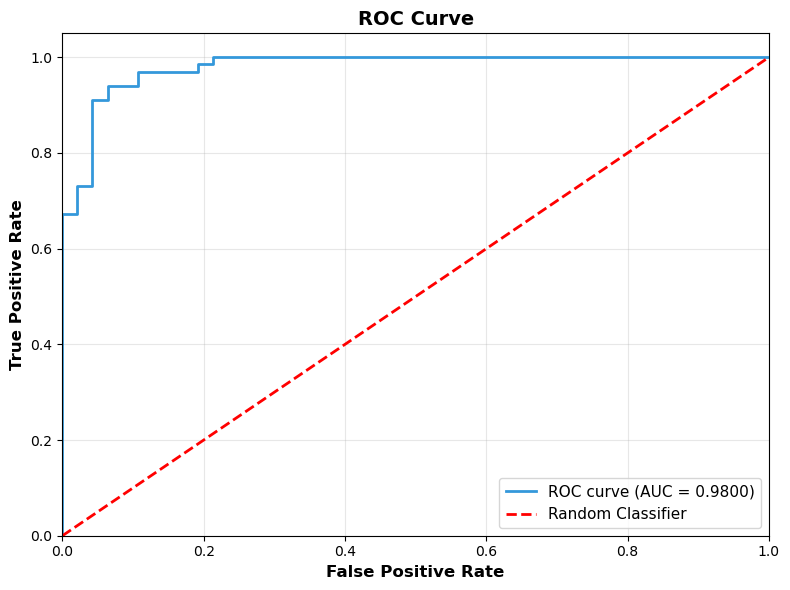

Area Under the Curve (AUC): 0.9800


In [15]:
fpr, tpr, thresholds = roc_curve(y_test_array, probabilities)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color="#3498db", lw=2, label=f"ROC curve (AUC = {roc_auc:.4f})")
ax.plot([0, 1], [0, 1], color="red", lw=2, linestyle="--", label="Random Classifier")
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel("False Positive Rate", fontsize=12, fontweight="bold")
ax.set_ylabel("True Positive Rate", fontsize=12, fontweight="bold")
ax.set_title("ROC Curve", fontsize=14, fontweight="bold")
ax.legend(loc="lower right", fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Area Under the Curve (AUC): {roc_auc:.4f}")